In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pwd

'/Users/henryhampton/Library/CloudStorage/OneDrive-UNSW/2026_06_17_Code_for_upload/T_cell_cytof_figure/code'

In [3]:
# Import data
cells = pd.read_csv('../data/cd8_t_cells_cd8_low_removed_umap_patient_updated.csv', index_col = 0)
#cells.columns

In [4]:
# Read in a file which details the cell type of each cluster
cluster_result = pd.read_excel('../data/2024_06_25_Annotations.xlsx')
cell_type_dict = dict(zip(cluster_result['FlowSOM_Cluster'], cluster_result['Annotation']))
cell_type_dict

{1: 'CD56pos_GzmBpos',
 2: 'CD56pos_GzmBpos',
 3: 'CD56pos_GzmBpos',
 4: 'CD56pos_GzmBpos',
 5: 'CD56pos_GzmBpos',
 6: 'CD56neg_GzmBpos',
 7: 'CD56neg_GzmBpos',
 8: 'CD56pos_GzmBpos',
 9: 'CD56neg_GzmBpos',
 10: 'CD56neg_GzmBpos',
 11: 'CD56neg_GzmBpos',
 12: 'CD56pos_GzmBpos',
 13: 'CD56pos_CD127neg_Trm',
 14: 'CD56pos_GzmBpos',
 15: 'CD56pos_GzmBpos',
 16: 'CD56neg_GzmBpos',
 17: 'Activated',
 18: 'CD56pos_CD127pos_Trm',
 19: 'CD56pos_CD127neg_Trm',
 20: 'CD56pos_GzmBpos',
 21: 'CD56neg_GzmBpos',
 22: 'CD56neg_GzmBpos',
 23: 'CD56pos_CD127neg_Trm',
 24: 'CD56neg_GzmBpos',
 25: 'CD56neg_GzmBpos',
 26: 'CD56pos_CD127neg_Trm',
 27: 'CD56neg_CD127neg_Trm',
 28: 'CD56neg_GzmBpos',
 29: 'CD56neg_GzmBpos',
 30: 'CD56neg_CD127neg_Trm',
 31: 'Memory',
 32: 'CD56neg_GzmBpos',
 33: 'CD56neg_CD127pos_Trm',
 34: 'CD56neg_GzmBpos',
 35: 'Naïve/Memory',
 36: 'Memory',
 37: 'Memory',
 38: 'CD56neg_GzmBpos',
 39: 'Activated',
 40: 'CD56pos_GzmBpos'}

In [5]:
# Map the cell types to the flowsom metacluster
cells['cell_type'] = cells['FlowSOM_metacluster'].map(cell_type_dict)


In [6]:
# Alter the column names to make it easier to produce graphs
cells.columns = cells.columns.str.replace('_asinh_coarseAlign_fineAlign', '')
cells.columns.values[35:62] = cells.columns[35:62].str.replace(r'^\d{3}[A-Za-z]{2}_', '', regex=True)
cells.columns

cells.columns = cells.columns.str.replace('176Yb_CD56', 'CD56')
cells.columns = cells.columns.str.replace('Granzyme_B', 'GZMB')
cells.columns = cells.columns.str.replace('CD279_PD1', 'PD1')
cells.columns = cells.columns.str.replace('CD197_CCR7', 'CCR7')

In [7]:
# # Create a list of markers that I might be interested in plotting
markers = ['CD38', 'Ki67',  'CD39', 'PD1',
       'CD127', 'CD57', 'Perforin', 'CD45RA', 'CD69',
       'CD8a', 'KLRG1', 'CD45RO', 'GZMB', 'HLA-DR', 'CD56']

In [8]:
# Calculate the geometric mean of expression
pseudocount = 0.01  # you can adjust this value

# Calculate geometric mean with pseudocount
expression_matrix = cells.groupby('cell_type')[markers].apply(
    lambda x: np.exp(np.log(x + pseudocount).mean())
).T

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


In [9]:
expression_matrix

cell_type,Activated,CD56neg_CD127neg_Trm,CD56neg_CD127pos_Trm,CD56neg_GzmBpos,CD56pos_CD127neg_Trm,CD56pos_CD127pos_Trm,CD56pos_GzmBpos,Memory,Naïve/Memory
CD38,0.944831,0.303973,0.317041,0.543357,0.397341,0.261291,0.604118,0.167025,0.177113
Ki67,0.140363,0.122703,0.118758,0.166854,0.136684,0.125527,0.174059,0.141740,0.126697
CD39,0.089780,0.085005,0.086423,0.085248,0.093149,0.082355,0.086473,0.090734,0.080824
PD1,1.228859,0.476651,0.333247,0.180223,0.172062,0.209487,0.074165,0.400353,0.099896
CD127,0.041582,0.060397,2.661693,0.082360,0.042827,2.447127,0.070012,0.818595,1.262184
CD57,0.719070,0.817813,0.667020,1.780988,0.882743,0.678002,2.648828,0.779146,0.654807
Perforin,0.591304,0.472750,0.402478,2.451726,0.897496,1.087440,3.843329,0.519541,0.179511
CD45RA,0.208570,0.690000,0.239425,0.919634,1.348033,0.187292,1.934362,0.310578,0.422610
CD69,2.848633,1.791477,2.822991,0.141801,2.182825,0.863108,0.190998,0.126366,0.084369
CD8a,2.559148,2.482306,2.807291,2.584683,2.344645,2.254713,2.590787,2.691069,2.577176


In [10]:
# def create_flow_dotplot(data, markers, cell_types, expression_matrix, percent_matrix, 
#                        figsize=(6, 4), dot_scale=40, cmap='viridis', cell_colors=None):
    
#     # Ensure matrices have correct orientation and order
#     expression_matrix = expression_matrix.loc[markers, cell_types]
#     percent_matrix = percent_matrix.loc[markers, cell_types]
    
#     # Debug prints
#     print("Matrix shapes after reordering:")
#     print(f"Expression matrix shape: {expression_matrix.shape}")
#     print(f"Expression matrix index: {expression_matrix.index[:5]}")
#     print(f"Expression matrix columns: {expression_matrix.columns[:5]}")
    
#     # Create figure
#     fig, ax = plt.subplots(figsize=figsize)
    
#     # Create a list to store scatter objects
#     scatter_objects = []
#     # Plot each point individually to ensure correct mapping
#     for i, marker in enumerate(markers):
#         for j, cell_type in enumerate(cell_types):
#             sc = ax.scatter(j, i,
#                       s=percent_matrix.loc[marker, cell_type] * dot_scale,
#                       c=[expression_matrix.loc[marker, cell_type]],
#                       cmap=cmap,
#                       vmin=expression_matrix.values.min(),
#                       vmax=expression_matrix.values.max())
#             scatter_objects.append(sc)
    
#     # Customize axis
#     ax.set_xticks(range(len(cell_types)))
#     ax.set_yticks(range(len(markers)))
#     ax.set_xticklabels(cell_types, rotation=90)
#     ax.set_yticklabels(markers)
#     ax.tick_params(axis='both', labelsize=7, pad=1, length=1.5) 
    
#     # Add expression colorbar
#     if scatter_objects:
#         colorbar = plt.colorbar(scatter_objects[-1], ax=ax)
#         colorbar.set_label('Mean Expression', rotation=270, fontsize=7, labelpad=10)
#         colorbar.ax.tick_params(labelsize=7, pad=1, length=1.5)
    
#     # Add size legend
#     sizes = [25, 50, 75, 100]
#     legend_elements = [plt.scatter([], [], s=size*dot_scale, 
#                                  c='gray', alpha=0.5, 
#                                  label=f'{size}%') 
#                       for size in sizes]
#     # Plot the legend
#     ax.legend(handles=legend_elements, 
#              title='% Cells\nExpressing', 
#              loc='center left',
#              fontsize=7, labelspacing=1,
#              title_fontsize=7,
#              frameon=False,
#              bbox_to_anchor=(1.25, 0.5))
    
#     # Add cell type colorbar at the bottom if cell_colors is provided
#     if cell_colors:
#         from mpl_toolkits.axes_grid1 import make_axes_locatable
#         import matplotlib.colors
        
#         # Create an array for cell type indices
#         cell_indices = np.arange(len(cell_types))
        
#         # Make a new axis for the cell type colorbar
#         divider = make_axes_locatable(ax)
#         cax = divider.append_axes("bottom", size="2%", pad=0.5)
        
#         # Create colors array in the order of cell_types
#         color_array = [cell_colors.get(ct, '#000000') for ct in cell_types]
        
#         # Create a custom colormap from the colors
#         cmap_cell = matplotlib.colors.ListedColormap(color_array)
#         norm = matplotlib.colors.BoundaryNorm(np.arange(len(cell_types)+1)-0.5, len(cell_types))
        
#         # Create the colorbar
#         cell_cbar = matplotlib.colorbar.ColorbarBase(
#             cax, cmap=cmap_cell, norm=norm, orientation='horizontal')
        
#         # Remove tick labels (since we already have them on the main plot)
#         cell_cbar.set_ticks([])
#         cell_cbar.outline.set_visible(False)
        
#         # Add a label
#         cax.set_xlabel('Cell Types', fontsize=7)
    
#     plt.grid(False)
#     plt.tight_layout()
#     return fig, ax

In [11]:
def create_flow_dotplot(data, markers, cell_types, expression_matrix, percent_matrix, 
                       figsize=(6, 4), dot_scale=40, cmap='viridis', cell_colors=None,
                       show_y_labels=True):
    
    expression_matrix = expression_matrix.loc[cell_types, markers]
    percent_matrix = percent_matrix.loc[cell_types, markers]
    
    fig, ax = plt.subplots(figsize=figsize)
    
    scatter_objects = []
    for i, marker in enumerate(markers):
        for j, cell_type in enumerate(cell_types):
            sc = ax.scatter(i, j,
          s=percent_matrix.loc[cell_type, marker] * dot_scale,
          c=[expression_matrix.loc[cell_type, marker]],
          cmap='Greys',
          vmin=expression_matrix.values.min(),
          vmax=expression_matrix.values.max(),
          edgecolors='black',  
          linewidths=0.3)     
            scatter_objects.append(sc)
    
    # markers on x-axis, cell_types on y-axis
    ax.set_xticks(range(len(markers)))
    ax.set_xticklabels(markers, rotation=90)
    ax.set_yticks(range(len(cell_types)))
    
    if show_y_labels:
        ax.set_yticklabels(cell_types)
    else:
        ax.set_yticklabels([])
    
    ax.tick_params(axis='both', labelsize=7, pad=1, length=1.5) 
    
    if scatter_objects:
        colorbar = plt.colorbar(scatter_objects[-1], ax=ax)
        colorbar.set_label('Mean Expression', rotation=270, fontsize=7, labelpad=10)
        colorbar.ax.tick_params(labelsize=7, pad=1, length=1.5)
    
    sizes = [25, 50, 75, 100]
    legend_elements = [plt.scatter([], [], s=size*dot_scale, 
                                 c='gray', alpha=0.5, 
                                 label=f'{size}%') 
                      for size in sizes]
    ax.legend(handles=legend_elements, 
             title='% Cells\nExpressing', 
             loc='center left',
             fontsize=7, labelspacing=1,
             title_fontsize=7,
             frameon=False,
             bbox_to_anchor=(1.25, 0.5))
    
    if cell_colors:
        from mpl_toolkits.axes_grid1 import make_axes_locatable
        import matplotlib.colors
        
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("left", size="2%", pad=0.1)  # <-- moved to left
        
        color_array = [cell_colors.get(ct, '#000000') for ct in cell_types]
        cmap_cell = matplotlib.colors.ListedColormap(color_array)
        norm = matplotlib.colors.BoundaryNorm(np.arange(len(cell_types)+1)-0.5, len(cell_types))
        
        cell_cbar = matplotlib.colorbar.ColorbarBase(
            cax, cmap=cmap_cell, norm=norm, orientation='vertical')  # <-- vertical
        cell_cbar.set_ticks([])
        cell_cbar.outline.set_visible(False)
    
    plt.grid(False)
    plt.tight_layout()
    return fig, ax

In [12]:
# Rename the columns
cells.columns = cells.columns.str.replace('176Yb_CD56', 'CD56')
cells.columns = cells.columns.str.replace('Granzyme_B', 'GZMB')
cells.columns = cells.columns.str.replace('CD279_PD1', 'PD1')
cells.columns = cells.columns.str.replace('CD197_CCR7', 'CCR7')


In [13]:
# Add colours for color bar
colours = pd.read_excel('../data/2025_12_15_Cell_color_table.xlsx')


color_dict = dict(zip(colours['Cell_type'], colours['Color']))

print(color_dict)

{'Naïve/Memory': '#F1C40FFF', 'Memory': '#2ECC71FF', 'Activated': '#F39C12FF', 'CD56neg_CD127pos_Trm': '#E74C3CFF', 'CD56neg_CD127neg_Trm': '#34495EFF', 'CD56pos_CD127pos_Trm': '#9B59B6FF', 'CD56pos_CD127neg_Trm': '#1ABC9CFF', 'CD56neg_GzmBpos': '#3498DBFF', 'CD56pos_GzmBpos': '#D35400FF'}


In [14]:
desired_cell_type_order = ['CD56pos_GzmBpos',
 'CD56neg_GzmBpos',
 'CD56pos_CD127neg_Trm',
 'CD56pos_CD127pos_Trm',
 'CD56neg_CD127neg_Trm',
 'CD56neg_CD127pos_Trm',
 'Activated',
 'Memory',
 'Naïve/Memory']

In [15]:
expression_matrix

cell_type,Activated,CD56neg_CD127neg_Trm,CD56neg_CD127pos_Trm,CD56neg_GzmBpos,CD56pos_CD127neg_Trm,CD56pos_CD127pos_Trm,CD56pos_GzmBpos,Memory,Naïve/Memory
CD38,0.944831,0.303973,0.317041,0.543357,0.397341,0.261291,0.604118,0.167025,0.177113
Ki67,0.140363,0.122703,0.118758,0.166854,0.136684,0.125527,0.174059,0.141740,0.126697
CD39,0.089780,0.085005,0.086423,0.085248,0.093149,0.082355,0.086473,0.090734,0.080824
PD1,1.228859,0.476651,0.333247,0.180223,0.172062,0.209487,0.074165,0.400353,0.099896
CD127,0.041582,0.060397,2.661693,0.082360,0.042827,2.447127,0.070012,0.818595,1.262184
CD57,0.719070,0.817813,0.667020,1.780988,0.882743,0.678002,2.648828,0.779146,0.654807
Perforin,0.591304,0.472750,0.402478,2.451726,0.897496,1.087440,3.843329,0.519541,0.179511
CD45RA,0.208570,0.690000,0.239425,0.919634,1.348033,0.187292,1.934362,0.310578,0.422610
CD69,2.848633,1.791477,2.822991,0.141801,2.182825,0.863108,0.190998,0.126366,0.084369
CD8a,2.559148,2.482306,2.807291,2.584683,2.344645,2.254713,2.590787,2.691069,2.577176


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_8627/2523371286.py:42: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '41.40522875816993' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  percent_matrix.loc[cell_type, marker] = percent_above
/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_8627/2523371286.py:42: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10.702614379084967' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  percent_matrix.loc[cell_type, marker] = percent_above
/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_8627/2523371286.py:42: Fu

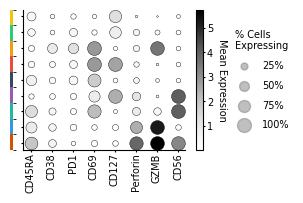

In [16]:
# Make the dot plot 
plt.rcParams['svg.fonttype'] = 'none' 
plt.rcParams['pdf.fonttype'] = 'truetype'


# Calculate geometric mean with pseudocount
pseudocount = 0.01 
# Group by cell_type to get expression values
expression_matrix = cells.groupby('cell_type')[markers].apply(
    lambda x: np.exp(np.log(x + pseudocount).mean())
)   # Remove the .T here

cell_types = ['Naïve/Memory', 'Memory', 'Activated','CD56neg_CD127pos_Trm', 'CD56neg_CD127neg_Trm',  
                          'CD56pos_CD127pos_Trm', 
                          'CD56pos_CD127neg_Trm', 'CD56neg_GzmBpos',
                          'CD56pos_GzmBpos']

# Initialize percent matrix with cell types as index
percent_matrix = pd.DataFrame(
    index=cell_types,
)
# Define your desired column order
desired_cell_type_order = ['Naïve/Memory', 'Memory', 'Activated','CD56neg_CD127pos_Trm', 'CD56neg_CD127neg_Trm',  
                          'CD56pos_CD127pos_Trm', 
                          'CD56pos_CD127neg_Trm', 'CD56neg_GzmBpos',
                          'CD56pos_GzmBpos']
desired_cell_type_order = desired_cell_type_order[::-1]

exp_dict = {'CD45RA' : 1, 'CD38' :1.4,
         'PD1' : 2, 'CD69' : 1,
         'CD127' : 1, 'Perforin' : 1.75,  
         'GZMB' : 2,  'CD56' : 1}

markers = [key for key in exp_dict.keys()]
for marker in markers:
    threshold = exp_dict[marker]
    for cell_type in cell_types:
        mask = cells['cell_type'] == cell_type
        percent_above = (cells.loc[mask, marker] > threshold).mean() * 100
        if marker not in percent_matrix.columns:
            percent_matrix[marker] = 0
        percent_matrix.loc[cell_type, marker] = percent_above


# Reorder rows to match desired cell type order
expression_matrix = expression_matrix.reindex(desired_cell_type_order)
percent_matrix = percent_matrix.reindex(desired_cell_type_order)

# Create color dictionary for cell types

# Create the plot
fig, ax = create_flow_dotplot(
    data=cells,
    markers=markers,
    cell_types=desired_cell_type_order,
    expression_matrix=expression_matrix,
    percent_matrix=percent_matrix,
    figsize=(3, 2),
    cell_colors=color_dict,
    dot_scale=1, show_y_labels= False
)
ax.set_xticklabels(markers)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)  
fig.tight_layout(pad=0.6)
fig.savefig('../results/cd8_dot_plot_rotated_grey.pdf', bbox_inches='tight', pad_inches=0.01, dpi=600)
# fig.savefig('cd8_dot_plot_rotated_grey.png', bbox_inches='tight', pad_inches=0.01, dpi=600)

In [42]:
cells['Patient_ID'].unique()

array(['P08', 'P24', 'P19', 'P12', 'P04', 'P03', 'P27', 'P38', 'P06',
       'P10', 'P16', 'P14', 'P05', 'P02', 'P01', 'P11', 'P28', 'P07',
       'P15', 'P20', 'P26', 'P17', 'P18', 'P22', 'P25', 'P13', 'P21',
       'Control_14', 'Control_1', 'Control_17', 'Control_19',
       'Control_13', 'Control_18', 'Control_9', 'Control_7', 'Control_15',
       'Control_3', 'Control_2', 'Control_6', 'Control_8', 'Control_5',
       'Control_16', 'Control_10', 'Control_4', 'Control_12',
       'Control_11'], dtype=object)